In [28]:
%pip -q install obspy scipy pandas opencv-python-headless matplotlib

In [1]:
"""
Google Colab용 실제 지진파 이미지 준비 코드 v6

핵심 아이디어
- 실제 3성분 파형을 FDSN/EarthScope 라우터에서 내려받음
- 한 관측소당 1장의 'DUAL_PROGRAM.png' 생성
    위 패널: Z(수직) 성분 -> P파 탐지용
    아래 패널: 수평 2성분 합성 진폭 -> S파 탐지용
- 이미지 생성 뒤, 실제 분석 코드와 동일한 픽셀 기반 detector로 P/S를 다시 탐지
- TauP/IASP91의 이론 P/S는 detector에 주지 않고, 탐지 후 품질평가에만 사용
- P/S, 특히 S-P 오차가 충분히 작은 관측소 중 방위각이 분산된 3개만 선택
- 조건을 만족하는 3개 조합이 없으면 억지로 나쁜 조합을 반환하지 않고 종료

Colab 첫 셀:
    %pip -q install obspy scipy pandas opencv-python-headless matplotlib

그 다음 이 파일을 업로드하고:
    exec(open('prepare_real_earthquake_dual_v6.py', encoding='utf-8').read(), globals())
    results, zip_path = prepare_event('nepal_2015')
"""

from __future__ import annotations

import json
import math
import shutil
import zipfile
from dataclasses import dataclass, asdict
from pathlib import Path
from itertools import combinations

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from obspy import UTCDateTime, Stream
from obspy.clients.fdsn import RoutingClient
from obspy.geodetics.base import gps2dist_azimuth, kilometers2degrees
from obspy.taup import TauPyModel

# ============================================================
# 설정
# ============================================================
OUT_ROOT = Path("real_earthquake_dual_v6")
OUT_ROOT.mkdir(exist_ok=True)

TAUP = TauPyModel(model="iasp91")
ROUTER_NAMES = ["earthscope-federator", "eida-routing"]
CHANNEL_PREFIX_PRIORITY = ["HN", "BN", "HH", "BH", "EH", "SH", "LH", "MH"]

EVENTS = {
    "nepal_2015": {
        "label": "2015 Nepal (Gorkha) Mw7.8",
        "origin": "2015-04-25T06:11:25.950",
        "lat": 28.231,
        "lon": 84.731,
        "depth_km": 8.2,
        "minradius": 0.20,
        "maxradius": 10.0,
        "net_hint": "IO,NQ,NP,CB,IC,IU,GE,ZO,Z6,IN,BI,*",
        "band": (0.10, 5.0),
    },
    "turkey_2023": {
        "label": "2023 Türkiye Pazarcik Mw7.8",
        "origin": "2023-02-06T01:17:34.342",
        "lat": 37.226,
        "lon": 37.014,
        "depth_km": 10.0,
        "minradius": 0.20,
        "maxradius": 6.0,
        "net_hint": "TK,TU,KO,GE,IU,II,*",
        "band": (0.10, 8.0),
    },
    "sumatra_2004": {
        "label": "2004 Sumatra-Andaman Mw9.1",
        "origin": "2004-12-26T00:58:53.000",
        "lat": 3.295,
        "lon": 95.982,
        "depth_km": 30.0,
        "minradius": 1.0,
        "maxradius": 22.0,
        "net_hint": "IU,II,GE,MY,PS,JP,*",
        "band": (0.03, 2.0),
    },
}

# 후보 detector 통과 기준. 너무 엄격해서 0개가 되는 것을 막되,
# 위치결정에 직접 중요한 S-P 오차는 상대적으로 엄격하게 둔다.
MAX_P_ERR_S = 10.0
MAX_S_ERR_S = 10.0
MAX_SP_ERR_S = 5.0
STRICT_MIN_AZ_SEP_DEG = 30.0
RELAXED_MIN_AZ_SEP_DEG = 22.0
MAX_DISTANCE_KM = 900.0
MAX_CANDIDATES_TO_TRY = 100

# DUAL 이미지 고정 포맷
DUAL_WIDTH = 2400
DUAL_HEIGHT = 800
DUAL_X_MARGIN = 18
DUAL_PANEL_GAP = 36


@dataclass
class Candidate:
    net: str
    sta: str
    loc: str
    prefix: str
    lat: float
    lon: float
    distance_km: float
    azimuth_deg: float


@dataclass
class StationResult:
    station_index: int
    name: str
    net: str
    sta: str
    loc: str
    prefix: str
    lat: float
    lon: float
    distance_km_geo: float
    azimuth_deg: float
    plot_start_s: float
    plot_end_s: float
    taup_p_s: float
    taup_s_s: float
    taup_sp_s: float
    detected_p_s: float
    detected_s_s: float
    detected_sp_s: float
    p_error_s: float
    s_error_s: float
    sp_error_s: float
    quality: float
    dual_program_png: str
    dual_reference_png: str
    raw3c_png: str


# ============================================================
# 공통 수치 유틸
# ============================================================
def robust_scale(x):
    x = np.asarray(x, dtype=float)
    s = np.nanpercentile(np.abs(x), 99.5)
    if not np.isfinite(s) or s <= 1e-12:
        s = np.nanstd(x)
    return max(float(s), 1e-12)


def smooth_1d(x, n):
    x = np.asarray(x, dtype=float)
    n = max(1, int(n))
    if n <= 1:
        return x.copy()
    k = np.ones(n, dtype=float) / n
    return np.convolve(x, k, mode="same")


def trailing_mean(x, n):
    x = np.asarray(x, dtype=float)
    n = max(1, int(n))
    out = np.full(len(x), np.nan, dtype=float)
    if len(x) < n:
        return out
    cs = np.cumsum(np.insert(x, 0, 0.0))
    out[n-1:] = (cs[n:] - cs[:-n]) / n
    return out


def first_sustained(mask, start, length):
    start = max(0, int(start))
    length = max(1, int(length))
    c = 0
    for i in range(start, len(mask)):
        if bool(mask[i]):
            c += 1
            if c >= length:
                return i - length + 1
        else:
            c = 0
    return None


def angular_sep(a, b):
    d = abs(float(a) - float(b)) % 360.0
    return min(d, 360.0 - d)


# ============================================================
# FDSN 관측소 검색/다운로드
# ============================================================
def get_routers():
    routers = []
    for name in ROUTER_NAMES:
        try:
            routers.append((name, RoutingClient(name, timeout=90)))
        except Exception as e:
            print(f"[경고] {name} 라우터 생성 실패: {e}")
    if not routers:
        raise RuntimeError("사용 가능한 FDSN 라우터가 없습니다.")
    return routers


def merge_inventories(inventories):
    out = None
    for inv in inventories:
        if inv is None:
            continue
        if out is None:
            out = inv
        else:
            try:
                out += inv
            except Exception:
                pass
    return out


def search_inventory(routers, ev, t0, duration=1000):
    inventories = []
    end = t0 + duration
    for netq in [ev.get("net_hint", "*"), "*"]:
        for rname, router in routers:
            try:
                print(f"  메타데이터 검색: router={rname}, network={netq}")
                inv = router.get_stations(
                    network=netq,
                    station="*",
                    location="*",
                    channel="HN?,BN?,HH?,BH?,EH?,SH?,LH?,MH?",
                    starttime=t0,
                    endtime=end,
                    latitude=ev["lat"],
                    longitude=ev["lon"],
                    minradius=ev["minradius"],
                    maxradius=ev["maxradius"],
                    level="channel",
                )
                inventories.append(inv)
            except Exception as e:
                print(f"    검색 실패({rname}): {type(e).__name__}: {e}")
        merged = merge_inventories(inventories)
        if merged is not None and sum(len(net.stations) for net in merged) >= 3:
            return merged
    merged = merge_inventories(inventories)
    if merged is None:
        raise RuntimeError("주변 관측소 메타데이터를 찾지 못했습니다.")
    return merged


def inventory_to_candidates(inv, ev):
    groups = {}
    for net in inv:
        for sta in net:
            for cha in sta:
                code = cha.code or ""
                if len(code) != 3:
                    continue
                prefix = code[:2]
                comp = code[-1].upper()
                if prefix not in CHANNEL_PREFIX_PRIORITY:
                    continue
                key = (
                    net.code, sta.code, cha.location_code or "", prefix,
                    float(sta.latitude), float(sta.longitude)
                )
                groups.setdefault(key, set()).add(comp)

    out = []
    for (net, sta, loc, prefix, lat, lon), comps in groups.items():
        has_z = "Z" in comps
        horiz = comps.intersection({"N", "E", "1", "2", "R", "T"})
        if not has_z or len(horiz) < 2:
            continue
        dist_m, az, _ = gps2dist_azimuth(ev["lat"], ev["lon"], lat, lon)
        dkm = dist_m / 1000.0
        if dkm > MAX_DISTANCE_KM:
            continue
        out.append(Candidate(
            net=net, sta=sta, loc=loc, prefix=prefix,
            lat=lat, lon=lon, distance_km=dkm, azimuth_deg=az % 360.0
        ))
    rank = {p: i for i, p in enumerate(CHANNEL_PREFIX_PRIORITY)}
    out.sort(key=lambda c: (c.distance_km, rank.get(c.prefix, 999)))
    return out


def fetch_waveforms(routers, cand, t0, endtime):
    errors = []
    for rname, router in routers:
        try:
            st = router.get_waveforms(
                network=cand.net,
                station=cand.sta,
                location=cand.loc if cand.loc else "*",
                channel=f"{cand.prefix}?",
                starttime=t0,
                endtime=endtime,
            )
            if len(st) == 0:
                raise RuntimeError("empty stream")
            try:
                st.merge(method=1, fill_value="interpolate")
            except Exception:
                pass
            return st, rname
        except Exception as e:
            errors.append(f"{rname}: {type(e).__name__}: {e}")
    raise RuntimeError(" | ".join(errors))


def select_three_components(st: Stream, prefix: str):
    comp = {}
    for tr in st:
        if not tr.stats.channel.startswith(prefix):
            continue
        comp.setdefault(tr.stats.channel[-1].upper(), tr)
    if "Z" not in comp:
        raise RuntimeError("Z component 없음")
    for a, b in [("N", "E"), ("1", "2"), ("R", "T")]:
        if a in comp and b in comp:
            return comp["Z"].copy(), comp[a].copy(), comp[b].copy()
    horiz = [k for k in comp if k != "Z"]
    if len(horiz) < 2:
        raise RuntimeError("수평 2성분 없음")
    return comp["Z"].copy(), comp[horiz[0]].copy(), comp[horiz[1]].copy()


def preprocess_components(z, h1, h2, start, end, band):
    traces = [z, h1, h2]
    common_start = max(tr.stats.starttime for tr in traces)
    common_end = min(tr.stats.endtime for tr in traces)
    common_start = max(common_start, start)
    common_end = min(common_end, end)
    if common_end <= common_start:
        raise RuntimeError("3성분 공통 시간구간 없음")

    fs = min(float(tr.stats.sampling_rate) for tr in traces)
    fs = float(np.clip(fs, 10.0, 50.0))
    out = []
    for tr0 in traces:
        tr = tr0.copy()
        tr.trim(common_start, common_end, pad=False)
        tr.detrend("demean")
        tr.detrend("linear")
        tr.taper(max_percentage=0.02, type="cosine")
        fmin, fmax = band
        nyq = 0.5 * float(tr.stats.sampling_rate)
        fmax_use = min(float(fmax), 0.80 * nyq)
        if float(fmin) < fmax_use:
            tr.filter("bandpass", freqmin=float(fmin), freqmax=fmax_use,
                      corners=4, zerophase=True)
        tr.interpolate(sampling_rate=fs, starttime=common_start, method="linear")
        out.append(tr)

    n = min(len(tr.data) for tr in out)
    if n < int(fs * 10):
        raise RuntimeError("파형 길이가 너무 짧음")
    vals = [np.asarray(tr.data[:n], dtype=float) for tr in out]
    time = np.arange(n, dtype=float) / fs + float(common_start - start)
    return time, vals[0], vals[1], vals[2], fs


# ============================================================
# Z/P + H/S용 신호 생성
# ============================================================
def make_dual_signals(z, h1, h2, fs):
    """이미지에 표시할 Z 파형과 수평 합성 진폭을 만든다."""
    zn = np.asarray(z, float) / robust_scale(z)
    h1n = np.asarray(h1, float) / robust_scale(h1)
    h2n = np.asarray(h2, float) / robust_scale(h2)

    # 수평 2성분의 벡터 크기: S파 에너지를 강조한다.
    hmag = np.sqrt(h1n**2 + h2n**2)
    # 극단치 한 점에 전체 스케일이 눌리지 않게 다시 robust normalization.
    hmag = hmag / robust_scale(hmag)

    # 이미지 해상도에 비해 너무 고주파인 선을 약간 정리한다.
    n_smooth = max(1, int(round(0.05 * fs)))
    zplot = smooth_1d(zn, n_smooth)
    hplot = smooth_1d(hmag, n_smooth)

    zplot = np.clip(zplot, -1.25, 1.25)
    hplot = np.clip(hplot, 0.0, 1.25)
    return zplot, hplot


def combined_energy(z, h1, h2):
    scale = max(robust_scale(z), robust_scale(h1), robust_scale(h2))
    return np.sqrt((z/scale)**2 + (h1/scale)**2 + (h2/scale)**2)


# ============================================================
# 고정 포맷 DUAL 이미지 저장
# ============================================================
def _resample_for_pixels(sig, npx):
    sig = np.asarray(sig, dtype=float)
    if len(sig) == npx:
        return sig
    x_old = np.linspace(0.0, 1.0, len(sig))
    x_new = np.linspace(0.0, 1.0, npx)
    return np.interp(x_new, x_old, sig)


def save_dual_program_png(path, zplot, hplot):
    """축/문자/정답선 없이, 위=Z 아래=H인 고정 포맷 이미지를 저장."""
    w, h = DUAL_WIDTH, DUAL_HEIGHT
    img = np.full((h, w, 3), 255, dtype=np.uint8)
    x0, x1 = DUAL_X_MARGIN, w - DUAL_X_MARGIN - 1
    npx = x1 - x0 + 1

    zpx = _resample_for_pixels(zplot, npx)
    hpx = _resample_for_pixels(hplot, npx)

    top_y0, top_y1 = 18, h//2 - DUAL_PANEL_GAP//2
    bot_y0, bot_y1 = h//2 + DUAL_PANEL_GAP//2, h - 18
    top_c = (top_y0 + top_y1) / 2.0
    bot_c = (bot_y0 + bot_y1) / 2.0
    top_amp = 0.43 * (top_y1 - top_y0)
    bot_amp = 0.82 * (bot_y1 - bot_y0)  # H는 위쪽으로만 그리므로 넓게 사용

    xs = np.arange(x0, x1 + 1, dtype=np.int32)
    zy = np.rint(top_c - np.clip(zpx, -1.0, 1.0) * top_amp).astype(np.int32)
    hy = np.rint(bot_y1 - 6 - np.clip(hpx, 0.0, 1.0) * bot_amp).astype(np.int32)

    zpts = np.column_stack([xs, zy]).reshape(-1, 1, 2)
    hpts = np.column_stack([xs, hy]).reshape(-1, 1, 2)
    cv2.polylines(img, [zpts], False, (0, 0, 0), 2, lineType=cv2.LINE_AA)
    cv2.polylines(img, [hpts], False, (0, 0, 0), 2, lineType=cv2.LINE_AA)

    # 아주 연한 중앙 분리선. detector는 이 영역을 읽지 않는다.
    cv2.line(img, (0, h//2), (w-1, h//2), (235,235,235), 1)
    if not cv2.imwrite(str(path), img):
        raise RuntimeError(f"이미지 저장 실패: {path}")


def save_dual_reference_png(path, time, zplot, hplot, p_s, s_s, title):
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    axes[0].plot(time, zplot, linewidth=0.7)
    axes[0].axvline(p_s, linestyle="--", label=f"TauP P={p_s:.2f}s")
    axes[0].set_ylabel("Z normalized")
    axes[0].legend()
    axes[1].plot(time, hplot, linewidth=0.7)
    axes[1].axvline(s_s, linestyle="--", label=f"TauP S={s_s:.2f}s")
    axes[1].set_ylabel("Horizontal magnitude")
    axes[1].set_xlabel("seconds after archive origin")
    axes[1].legend()
    axes[0].set_title(title)
    for ax in axes:
        ax.grid(alpha=0.2)
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.close(fig)


def save_raw3c(path, time, z, h1, h2, p_s, s_s, title):
    fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
    for ax, d, lab in zip(axes, [z,h1,h2], ["Z","H1","H2"]):
        ax.plot(time, d/robust_scale(d), linewidth=0.6)
        ax.axvline(p_s, linestyle="--", linewidth=1)
        ax.axvline(s_s, linestyle="--", linewidth=1)
        ax.set_ylabel(lab)
        ax.grid(alpha=0.2)
    axes[0].set_title(title + " - actual 3-component waveform")
    axes[-1].set_xlabel("seconds after archive origin")
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.close(fig)


# ============================================================
# DUAL 이미지 픽셀 detector (분석 코드와 동일 로직)
# ============================================================
def _dark_envelope_from_panel(gray_panel, baseline_mode="center"):
    """고정 포맷 패널의 검은 선을 x별 진폭 envelope로 변환."""
    p = cv2.GaussianBlur(gray_panel, (3,3), 0)
    darkness = 255.0 - p.astype(float)
    mask = darkness > 35.0
    hh, ww = mask.shape

    if baseline_mode == "center":
        baseline = 0.5 * (hh - 1)
        amp_scale = max(1.0, 0.45 * hh)
        env = np.zeros(ww, dtype=float)
        for x in range(ww):
            ys = np.flatnonzero(mask[:,x])
            if len(ys):
                # Z는 중앙 기준 절대편차
                env[x] = np.max(np.abs(ys - baseline)) / amp_scale
    else:
        # H는 초기 조용한 구간의 검은 선 위치를 실제 0 기준으로 추정.
        baseline_samples = []
        for x in range(max(10, int(0.08 * ww))):
            ys = np.flatnonzero(mask[:, x])
            if len(ys):
                baseline_samples.extend(ys.tolist())
        baseline = float(np.median(baseline_samples)) if baseline_samples else float(hh - 20)
        amp_scale = max(1.0, 0.82 * hh)
        env = np.zeros(ww, dtype=float)
        for x in range(ww):
            ys = np.flatnonzero(mask[:,x])
            if len(ys):
                env[x] = max(0.0, baseline - float(np.min(ys))) / amp_scale

    env = smooth_1d(env, 5)
    return env


def extract_dual_envelopes(image_bgr):
    if image_bgr is None:
        raise ValueError("이미지가 없습니다.")
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    if h < 300 or w < 500:
        raise ValueError("DUAL 이미지가 너무 작습니다.")
    gap = max(8, int(h * 0.025))
    top = gray[0:h//2-gap, :]
    bottom = gray[h//2+gap:h, :]
    zenv = _dark_envelope_from_panel(top, "center")
    henv = _dark_envelope_from_panel(bottom, "bottom")
    return zenv, henv


def _pixel_time(i, width, start_s, end_s):
    if width <= 1:
        return float(start_s)
    return float(start_s) + float(i)/(width-1) * (float(end_s)-float(start_s))


def detect_ps_from_dual_image(image_bgr, start_s, end_s):
    """이론 도착시각을 보지 않고 DUAL 이미지 자체만으로 P/S를 찾는다."""
    zenv, henv = extract_dual_envelopes(image_bgr)
    n = min(len(zenv), len(henv))
    zenv, henv = zenv[:n], henv[:n]
    duration = float(end_s) - float(start_s)
    if duration <= 0:
        raise ValueError("end_s는 start_s보다 커야 합니다.")
    px_per_s = (n - 1) / duration

    # ---------- P: Z 성분의 초기 잡음 대비 첫 지속 증가 ----------
    noise_n = int(np.clip(0.08*n, 30, 0.18*n))
    znoise = zenv[:noise_n]
    med = float(np.median(znoise))
    mad = float(np.median(np.abs(znoise-med)))
    sigma = 1.4826*mad + 1e-6
    zmax = float(np.max(zenv)) + 1e-9
    p_hi = max(med + 6.0*sigma, 0.035*zmax)
    p_lo = max(med + 2.7*sigma, 0.010*zmax)
    sustain = max(3, int(round(0.35*px_per_s)))
    p_cand = first_sustained(zenv > p_hi, max(3, int(0.02*n)), sustain)
    if p_cand is None:
        raise RuntimeError("Z 패널에서 P파를 찾지 못했습니다.")
    quiet = max(2, int(round(0.20*px_per_s)))
    p_idx = int(p_cand)
    qc = 0
    for i in range(p_cand-1, 0, -1):
        if zenv[i] > p_lo:
            p_idx = i
            qc = 0
        else:
            qc += 1
            if qc >= quiet:
                break

    # ---------- S: Horizontal의 새 에너지 증가 + H/Z 우세 ----------
    # 시간 단위 창을 픽셀로 변환해 이미지 길이에 덜 민감하게 함.
    e = henv**2
    sta_n = max(3, int(round(0.8*px_per_s)))
    lta_n = max(sta_n+4, int(round(6.0*px_per_s)))
    sta = trailing_mean(e, sta_n)
    lta = trailing_mean(e, lta_n)
    ratio = np.nan_to_num(sta/(lta+1e-9), nan=0.0, posinf=0.0)

    # Horizontal / Vertical의 부드러운 상대 에너지. S에서 수평 우세를 활용.
    smooth_n = max(3, int(round(0.6*px_per_s)))
    hs = smooth_1d(henv, smooth_n)
    zs = smooth_1d(zenv, smooth_n)
    hnoise = henv[:noise_n]
    hm = float(np.median(hnoise))
    hmad = float(np.median(np.abs(hnoise-hm)))
    hsigma = 1.4826*hmad + 1e-6
    h_abs_thr = max(hm + 5.0*hsigma, 0.045*float(np.max(henv)))
    pol = hs / (zs + max(hm, 0.01) + 1e-4)

    min_gap_s = max(1.5, min(4.0, 0.04*duration))
    s_start = max(p_idx + int(round(min_gap_s*px_per_s)), lta_n)
    s_end = min(n-1, int(round(0.90*n)))
    if s_start >= s_end:
        raise RuntimeError("S파 탐색 구간이 없습니다.")

    # 1차: STA/LTA + 절대 H 진폭을 동시에 만족하는 첫 번째 sustained onset.
    mask1 = (ratio > 1.85) & (hs > h_abs_thr)
    s_sustain = max(3, int(round(0.45*px_per_s)))
    s_cand = first_sustained(mask1[:s_end+1], s_start, s_sustain)

    # 2차: 1차 실패 시 H/Z 우세까지 포함한 물리적 fallback.
    if s_cand is None:
        mask2 = (ratio > 1.55) & (hs > h_abs_thr) & (pol > 1.15)
        s_cand = first_sustained(mask2[:s_end+1], s_start, s_sustain)

    # 3차: 여전히 없으면 '새로운 수평 에너지 증가' 점수의 첫 강한 피크.
    if s_cand is None:
        pre_n = max(3, int(round(4.0*px_per_s)))
        post_n = max(3, int(round(4.0*px_per_s)))
        scores = np.full(n, -np.inf)
        for i in range(max(s_start, pre_n), min(s_end, n-post_n)):
            pre = float(np.mean(hs[i-pre_n:i])) + 1e-6
            post = float(np.mean(hs[i:i+post_n])) + 1e-6
            if post > h_abs_thr:
                scores[i] = math.log(post/pre) + 0.25*math.log(post/(hm+1e-5))
        if np.isfinite(scores).any():
            best = int(np.nanargmax(scores))
            if scores[best] > 0.55:
                s_cand = best
    if s_cand is None:
        raise RuntimeError("Horizontal 패널에서 S파를 찾지 못했습니다.")

    # S onset을 후보에서 왼쪽으로 짧게 역추적.
    local_pre0 = max(s_start, s_cand - max(4, int(round(5*px_per_s))))
    local_pre = hs[local_pre0:s_cand]
    local_base = float(np.median(local_pre)) if len(local_pre) else hm
    s_lo = max(hm + 2.5*hsigma, local_base*1.15, 0.020*float(np.max(henv)))
    s_idx = int(s_cand)
    qc = 0
    for i in range(s_cand-1, s_start, -1):
        if hs[i] > s_lo:
            s_idx = i
            qc = 0
        else:
            qc += 1
            if qc >= quiet:
                break

    p_time = _pixel_time(p_idx, n, start_s, end_s)
    s_time = _pixel_time(s_idx, n, start_s, end_s)
    if s_time <= p_time:
        raise RuntimeError("S 도착시간이 P보다 앞서 계산되었습니다.")

    return {
        "p_idx": int(p_idx), "s_idx": int(s_idx),
        "p_time": float(p_time), "s_time": float(s_time),
        "sp_time": float(s_time-p_time),
        "z_envelope": zenv, "h_envelope": henv,
        "h_sta_lta": ratio, "h_over_z": pol,
    }


def evaluate_dual_png(path, start_s, end_s):
    img = cv2.imread(str(path))
    if img is None:
        raise FileNotFoundError(path)
    return detect_ps_from_dual_image(img, start_s, end_s)


# ============================================================
# 이론 P/S 및 품질
# ============================================================
def theoretical_ps(ev, station_lat, station_lon):
    dist_m, _, _ = gps2dist_azimuth(ev["lat"], ev["lon"], station_lat, station_lon)
    deg = kilometers2degrees(dist_m/1000.0)
    parr = TAUP.get_travel_times(
        source_depth_in_km=ev["depth_km"], distance_in_degree=deg,
        phase_list=["P","p","Pn","Pg"]
    )
    sarr = TAUP.get_travel_times(
        source_depth_in_km=ev["depth_km"], distance_in_degree=deg,
        phase_list=["S","s","Sn","Sg"]
    )
    if not parr or not sarr:
        allarr = TAUP.get_travel_times(source_depth_in_km=ev["depth_km"], distance_in_degree=deg)
        pt = [a.time for a in allarr if a.name.upper().startswith("P")]
        st = [a.time for a in allarr if a.name.upper().startswith("S")]
        if not pt or not st:
            raise RuntimeError("TauP P/S 계산 실패")
        return float(min(pt)), float(min(st))
    return float(min(a.time for a in parr)), float(min(a.time for a in sarr))


def snr_score(time, z, h1, h2, p_s, s_s):
    energy = combined_energy(z,h1,h2)
    noise_mask = (time >= 0) & (time <= max(1.0, p_s-3.0))
    p_mask = (time >= p_s) & (time <= min(s_s, p_s+max(6.0, 0.4*(s_s-p_s))))
    s_mask = (time >= s_s) & (time <= s_s+20.0)
    if noise_mask.sum()<5 or p_mask.sum()<5 or s_mask.sum()<5:
        return -np.inf
    noise = float(np.median(energy[noise_mask])) + 1e-9
    pl = float(np.percentile(energy[p_mask],90))
    sl = float(np.percentile(energy[s_mask],90))
    return float(np.log10((pl+1e-9)/noise)+np.log10((sl+1e-9)/noise))


# ============================================================
# 관측소 조합 선택
# ============================================================
def choose_three(valid_payloads):
    # payload dict 기반. 동일 물리 관측소 중 detector 오차가 가장 좋은 채널만 남긴다.
    best_by_station = {}
    for p in valid_payloads:
        key = (p["cand"].net, p["cand"].sta)
        score = p["sp_err"] + 0.25*(p["p_err"]+p["s_err"])
        if key not in best_by_station or score < best_by_station[key][0]:
            best_by_station[key] = (score, p)
    pool = [v[1] for v in best_by_station.values()]

    strict_candidates = [p for p in pool if (
        p["p_err"] <= MAX_P_ERR_S and p["s_err"] <= MAX_S_ERR_S and p["sp_err"] <= MAX_SP_ERR_S
    )]
    print(f"\nDUAL detector 개별 기준 통과 관측소: {len(strict_candidates)}개 / 서로 다른 관측소 {len(pool)}개")

    combos = []
    for combo in combinations(strict_candidates, 3):
        az = [p["cand"].azimuth_deg for p in combo]
        min_sep = min(angular_sep(az[0],az[1]), angular_sep(az[0],az[2]), angular_sep(az[1],az[2]))
        mean_sp = float(np.mean([p["sp_err"] for p in combo]))
        mean_abs = float(np.mean([p["p_err"]+p["s_err"] for p in combo]))
        mean_q = float(np.mean([p["quality"] for p in combo]))
        max_sp = float(np.max([p["sp_err"] for p in combo]))
        score = 2.0*min_sep - 12.0*mean_sp - 0.7*mean_abs + 1.5*mean_q - 4.0*max_sp
        tier = "strict" if min_sep >= STRICT_MIN_AZ_SEP_DEG else (
            "relaxed" if min_sep >= RELAXED_MIN_AZ_SEP_DEG else "rejected"
        )
        combos.append((tier, score, combo, min_sep))

    strict = [x for x in combos if x[0]=="strict"]
    relaxed = [x for x in combos if x[0]=="relaxed"]
    if strict:
        chosen = max(strict, key=lambda x:x[1])
    elif relaxed:
        chosen = max(relaxed, key=lambda x:x[1])
        print("[주의] 최소 방위각 30° 조합은 없고 22° 이상 조합을 사용합니다.")
    else:
        # 여기서 억지 fallback을 하지 않는다.
        # 대신 오류가 비교적 작은 근접 후보/방위각을 출력해 다음 판단에 도움을 준다.
        best = sorted(pool, key=lambda p:(p["sp_err"], p["p_err"]+p["s_err"]))[:10]
        print("\n[선택 실패] detector 오차와 방위각 조건을 동시에 만족하는 3관측소가 없습니다.")
        print("오차가 작은 후보 상위:")
        for p in best:
            c=p["cand"]
            print(f"  {c.net}.{c.sta} az={c.azimuth_deg:.0f}° Perr={p['p_err']:.2f}s Serr={p['s_err']:.2f}s SPerr={p['sp_err']:.2f}s")
        raise RuntimeError(
            "v6는 나쁜 3관측소 조합을 억지로 반환하지 않습니다. "
            "candidate_detector_audit.csv를 확인하세요."
        )
    return list(chosen[2]), chosen[0], float(chosen[3]), float(chosen[1])


# ============================================================
# 메인
# ============================================================
def prepare_event(event_key, routers=None):
    if event_key not in EVENTS:
        raise KeyError(f"지원 이벤트: {list(EVENTS)}")
    ev = EVENTS[event_key]
    t0 = UTCDateTime(ev["origin"])
    routers = routers or get_routers()

    outdir = OUT_ROOT/event_key
    if outdir.exists():
        shutil.rmtree(outdir)
    outdir.mkdir(parents=True)
    cand_dir = outdir/"_candidate_images"
    cand_dir.mkdir()

    print("\n"+"="*72)
    print(ev["label"])
    print(f"archive origin: {ev['origin']} UTC / {ev['lat']}, {ev['lon']} / depth {ev['depth_km']} km")
    print("="*72)

    inv = search_inventory(routers, ev, t0)
    candidates = inventory_to_candidates(inv, ev)
    print(f"후보 3성분 관측소 그룹: {len(candidates)}개")
    if len(candidates)<3:
        raise RuntimeError("후보가 3개 미만입니다.")

    valid = []
    audit = []
    for idx, cand in enumerate(candidates[:MAX_CANDIDATES_TO_TRY],1):
        print(f"\n후보 시험 {idx}/{min(len(candidates),MAX_CANDIDATES_TO_TRY)}: {cand.net}.{cand.sta}.{cand.loc}.{cand.prefix}?")
        row = dict(net=cand.net,sta=cand.sta,loc=cand.loc,prefix=cand.prefix,
                   lat=cand.lat,lon=cand.lon,distance_km=cand.distance_km,azimuth_deg=cand.azimuth_deg)
        try:
            tp, ts = theoretical_ps(ev,cand.lat,cand.lon)
            # origin부터 S 이후 충분한 구간까지. 이미지 시간 0은 archive origin에 대응.
            end_s = min(900.0, max(120.0, ts+60.0))
            st, router_name = fetch_waveforms(routers,cand,t0,t0+end_s)
            z,h1,h2 = select_three_components(st,cand.prefix)
            time,zv,h1v,h2v,fs = preprocess_components(z,h1,h2,t0,t0+end_s,ev["band"])
            if time[0] > 2.0:
                raise RuntimeError(f"기원시각 이후 데이터 시작이 너무 늦음: {time[0]:.2f}s")
            zplot,hplot = make_dual_signals(zv,h1v,h2v,fs)
            q = snr_score(time,zv,h1v,h2v,tp,ts)
            if not np.isfinite(q):
                raise RuntimeError("품질 점수 계산 실패")
            plot_start = float(time[0])
            plot_end = float(time[-1])
            # 이미지 자체는 실제 보유 시작/끝시간과 정확히 대응.
            cpath = cand_dir/f"cand_{idx:03d}_{cand.net}_{cand.sta}_{cand.loc or 'blank'}_{cand.prefix}_DUAL_PROGRAM.png"
            save_dual_program_png(cpath,zplot,hplot)
            det = evaluate_dual_png(cpath,plot_start,plot_end)
            p_err = abs(det["p_time"]-tp)
            s_err = abs(det["s_time"]-ts)
            sp_err = abs(det["sp_time"]-(ts-tp))
            print(
                f"  성공 {cand.net}.{cand.sta}: dist={cand.distance_km:.1f}km az={cand.azimuth_deg:.0f}° quality={q:.2f}\n"
                f"    TauP P={tp:.2f}s S={ts:.2f}s | DUAL IMAGE P={det['p_time']:.2f}s S={det['s_time']:.2f}s\n"
                f"    error P={p_err:.2f}s S={s_err:.2f}s S-P={sp_err:.2f}s"
            )
            payload = dict(cand=cand,tp=tp,ts=ts,time=time,z=zv,h1=h1v,h2=h2v,fs=fs,
                           zplot=zplot,hplot=hplot,quality=q,router=router_name,det=det,
                           p_err=p_err,s_err=s_err,sp_err=sp_err,
                           plot_start=plot_start,plot_end=plot_end)
            valid.append(payload)
            row.update(status="ok",quality=q,taup_p_s=tp,taup_s_s=ts,
                       detected_p_s=det["p_time"],detected_s_s=det["s_time"],
                       p_error_s=p_err,s_error_s=s_err,sp_error_s=sp_err,
                       pass_detector=(p_err<=MAX_P_ERR_S and s_err<=MAX_S_ERR_S and sp_err<=MAX_SP_ERR_S))
        except Exception as e:
            print(f"  실패 {cand.net}.{cand.sta}: {type(e).__name__}: {e}")
            row.update(status="failed",error=f"{type(e).__name__}: {e}")
        audit.append(row)

    audit_df = pd.DataFrame(audit)
    audit_df.to_csv(outdir/"candidate_detector_audit.csv",index=False)
    if len(valid)<3:
        raise RuntimeError(f"DUAL 이미지 분석까지 성공한 관측소가 {len(valid)}개뿐입니다.")

    selected,tier,min_sep,combo_score = choose_three(valid)
    print("\n최종 선택된 관측소 (v6 DUAL P/S + 기하):")
    for p in selected:
        c=p["cand"]
        print(f"  {c.net}.{c.sta} az={c.azimuth_deg:.0f}° dist={c.distance_km:.1f}km "
              f"Perr={p['p_err']:.2f}s Serr={p['s_err']:.2f}s SPerr={p['sp_err']:.2f}s")
    print(f"  -> tier={tier}, min azimuth separation={min_sep:.1f}°")

    results=[]
    for station_index,p in enumerate(selected,1):
        c=p["cand"]
        base=f"station{station_index}_{c.net}_{c.sta}_{c.loc or 'blank'}_{c.prefix}"
        prog=outdir/f"{base}_DUAL_PROGRAM.png"
        ref=outdir/f"{base}_DUAL_REFERENCE.png"
        raw=outdir/f"{base}_RAW3C.png"
        save_dual_program_png(prog,p["zplot"],p["hplot"])
        save_dual_reference_png(ref,p["time"],p["zplot"],p["hplot"],p["tp"],p["ts"],
                                f"{ev['label']} - {c.net}.{c.sta}")
        save_raw3c(raw,p["time"],p["z"],p["h1"],p["h2"],p["tp"],p["ts"],
                   f"{ev['label']} - {c.net}.{c.sta}")
        r=StationResult(
            station_index=station_index,name=f"{c.net}.{c.sta}",net=c.net,sta=c.sta,loc=c.loc,prefix=c.prefix,
            lat=c.lat,lon=c.lon,distance_km_geo=c.distance_km,azimuth_deg=c.azimuth_deg,
            plot_start_s=p["plot_start"],plot_end_s=p["plot_end"],
            taup_p_s=p["tp"],taup_s_s=p["ts"],taup_sp_s=p["ts"]-p["tp"],
            detected_p_s=p["det"]["p_time"],detected_s_s=p["det"]["s_time"],detected_sp_s=p["det"]["sp_time"],
            p_error_s=p["p_err"],s_error_s=p["s_err"],sp_error_s=p["sp_err"],quality=p["quality"],
            dual_program_png=prog.name,dual_reference_png=ref.name,raw3c_png=raw.name
        )
        results.append(r)

    df=pd.DataFrame([asdict(r) for r in results])
    df.to_csv(outdir/"station_metadata.csv",index=False)
    metadata={
        "event_key":event_key,"event":ev,"selection_version":"v6_dual",
        "selection_tier":tier,"min_azimuth_separation_deg":min_sep,"combination_score":combo_score,
        "detector_thresholds":{"max_p_err_s":MAX_P_ERR_S,"max_s_err_s":MAX_S_ERR_S,"max_sp_err_s":MAX_SP_ERR_S},
        "stations":[asdict(r) for r in results],
    }
    (outdir/"metadata.json").write_text(json.dumps(metadata,ensure_ascii=False,indent=2),encoding="utf-8")

    # 새 Colab에서 분석할 때 그대로 복붙 가능한 코드까지 출력 파일에 저장.
    lines=["# earthquake_dual_taup_analyzer_v6.py 실행 후 아래를 실행하세요.",
           "analyzer = DualWaveformTauPAnalyzer(taup_model='iasp91')"]
    for r in results:
        lines.append(f"analyzer.set_station_info({r.station_index}, name='{r.name}', lat={r.lat:.6f}, lon={r.lon:.6f})")
    lines.append("")
    for r in results:
        lines.append(f"# station {r.station_index}: {r.dual_program_png}")
        lines.append(f"# analyzer.upload_station({r.station_index}, start_time={r.plot_start_s:.3f}, end_time={r.plot_end_s:.3f})")
    lines.append("# result = analyzer.calculate_hypocenter()")
    (outdir/"COLAB_ANALYSIS_INPUT.txt").write_text("\n".join(lines),encoding="utf-8")

    # 임시 후보 이미지는 ZIP에서 제외
    if cand_dir.exists():
        shutil.rmtree(cand_dir)

    zip_path=OUT_ROOT/f"{event_key}_dual_v6_ready.zip"
    if zip_path.exists():
        zip_path.unlink()
    with zipfile.ZipFile(zip_path,"w",zipfile.ZIP_DEFLATED) as zf:
        for fp in outdir.iterdir():
            zf.write(fp,arcname=f"{event_key}/{fp.name}")

    print("\n완료")
    print(df[["station_index","name","lat","lon","azimuth_deg","taup_p_s","taup_s_s",
              "detected_p_s","detected_s_s","p_error_s","s_error_s","sp_error_s","plot_start_s","plot_end_s"]].to_string(index=False))
    print(f"결과 폴더: {outdir}")
    print(f"ZIP: {zip_path}")
    print("분석에는 *_DUAL_PROGRAM.png 3장만 넣으세요.")
    return results,zip_path


def prepare_all():
    routers=get_routers()
    out={}
    for key in EVENTS:
        try:
            out[key]=prepare_event(key,routers=routers)
        except Exception as e:
            print(f"[실패] {key}: {type(e).__name__}: {e}")
    return out


if __name__ == "__main__":
    print("Colab 권장. 먼저 `%pip -q install obspy scipy pandas opencv-python-headless matplotlib` 실행")
    print("그 뒤 예: results, zip_path = prepare_event('nepal_2015')")


Colab 권장. 먼저 `%pip -q install obspy scipy pandas opencv-python-headless matplotlib` 실행
그 뒤 예: results, zip_path = prepare_event('nepal_2015')


In [3]:
EVENTS.update({

    "ridgecrest_2019": {
        "label": "2019 Ridgecrest California M6.4",
        "origin": "2019-07-04T17:33:49.000",
        "lat": 35.705,
        "lon": -117.504,
        "depth_km": 10.5,

        # 너무 가까운 관측소는 포화/복잡한 near-field 파형을 피하기 위해 제외
        "minradius": 0.25,
        "maxradius": 4.0,

        "net_hint": "CI,NN,AZ,BK,PB,US,*",
        "band": (0.15, 8.0),
    },


    "amatrice_2016": {
        "label": "2016 Amatrice Italy M6.2",
        "origin": "2016-08-24T01:36:32.000",
        "lat": 42.723,
        "lon": 13.188,
        "depth_km": 4.4,

        "minradius": 0.20,
        "maxradius": 4.0,

        "net_hint": "IV,MN,*",
        "band": (0.15, 8.0),
    },


    "samos_2020": {
        "label": "2020 Samos Greece M7.0",
        "origin": "2020-10-30T11:51:27.000",
        "lat": 37.897,
        "lon": 26.784,
        "depth_km": 21.0,

        "minradius": 0.25,
        "maxradius": 5.0,

        "net_hint": "HL,HT,HA,HC,HP,KO,TU,GE,*",
        "band": (0.10, 6.0),
    },

})

In [4]:
results, zip_path = prepare_event("ridgecrest_2019")


2019 Ridgecrest California M6.4
archive origin: 2019-07-04T17:33:49.000 UTC / 35.705, -117.504 / depth 10.5 km
  메타데이터 검색: router=earthscope-federator, network=CI,NN,AZ,BK,PB,US,*
  메타데이터 검색: router=eida-routing, network=CI,NN,AZ,BK,PB,US,*
    검색 실패(eida-routing): FDSNNoDataException: No data available for request.
HTTP Status code: 204
Detailed response of server:

No Content -- 
후보 3성분 관측소 그룹: 898개

후보 시험 1/100: PB.B917..EH?
  성공 PB.B917: dist=40.0km az=146° quality=8.11
    TauP P=7.12s S=12.30s | DUAL IMAGE P=7.61s S=11.61s
    error P=0.49s S=0.69s S-P=1.17s

후보 시험 2/100: PB.B917..LH?
  성공 PB.B917: dist=40.0km az=146° quality=2.89
    TauP P=7.12s S=12.30s | DUAL IMAGE P=10.14s S=18.27s
    error P=3.01s S=5.98s S-P=2.96s

후보 시험 3/100: PB.B916..EH?
  성공 PB.B916: dist=56.1km az=345° quality=7.57
    TauP P=9.83s S=16.97s | DUAL IMAGE P=9.96s S=15.01s
    error P=0.13s S=1.96s S-P=2.09s

후보 시험 4/100: PB.B916..LH?
  성공 PB.B916: dist=56.1km az=345° quality=3.09
    TauP P=9.83s S=16

In [7]:
"""
Google Colab용 DUAL 지진파 이미지 분석 + TauP/IASP91 진원 위치결정 v6

입력 이미지 형식
- prepare_real_earthquake_dual_v6.py가 만든 *_DUAL_PROGRAM.png
- 위 패널: Z 성분(P 탐지)
- 아래 패널: 수평 합성 진폭(S 탐지)

위치결정
- 단순 Vp/Vs 거리식은 사용하지 않음
- TauP IASP91에서 후보 진원의 P/S 이론 도착시간 계산
- 관측소 3곳의 S-P와 관측소 간 P/S 상대 도착시간 차이를 동시에 맞춤
- 따라서 이미지의 공통 시작시각/기원시각 오프셋을 직접 알 필요가 없음
- 최종 해에서 공통 origin offset은 사후 추정값으로 출력

Colab 첫 셀:
    %pip -q install obspy scipy opencv-python-headless matplotlib pandas
"""

from __future__ import annotations

import math
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import least_squares
from obspy.taup import TauPyModel
from obspy.geodetics.base import locations2degrees

try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    files = None
    IN_COLAB = False


# ============================================================
# 이미지 detector 유틸 - preparer v6와 같은 로직
# ============================================================
def smooth_1d(x, n):
    x=np.asarray(x,float)
    n=max(1,int(n))
    if n<=1:
        return x.copy()
    return np.convolve(x,np.ones(n)/n,mode="same")


def trailing_mean(x,n):
    x=np.asarray(x,float)
    n=max(1,int(n))
    out=np.full(len(x),np.nan,float)
    if len(x)<n:
        return out
    cs=np.cumsum(np.insert(x,0,0.0))
    out[n-1:] = (cs[n:]-cs[:-n])/n
    return out


def first_sustained(mask,start,length):
    c=0
    start=max(0,int(start)); length=max(1,int(length))
    for i in range(start,len(mask)):
        if bool(mask[i]):
            c+=1
            if c>=length:
                return i-length+1
        else:
            c=0
    return None


def _dark_envelope_from_panel(gray_panel, baseline_mode="center"):
    p=cv2.GaussianBlur(gray_panel,(3,3),0)
    darkness=255.0-p.astype(float)
    mask=darkness>35.0
    hh,ww=mask.shape

    if baseline_mode=="center":
        baseline=0.5*(hh-1)
        amp_scale=max(1.0,0.45*hh)
        env=np.zeros(ww,float)
        for x in range(ww):
            ys=np.flatnonzero(mask[:,x])
            if len(ys):
                env[x]=np.max(np.abs(ys-baseline))/amp_scale
    else:
        # H는 초기 조용한 구간의 검은 선 위치를 실제 0 기준으로 추정.
        baseline_samples=[]
        for x in range(max(10,int(0.08*ww))):
            ys=np.flatnonzero(mask[:,x])
            if len(ys):
                baseline_samples.extend(ys.tolist())
        baseline=float(np.median(baseline_samples)) if baseline_samples else float(hh-20)
        amp_scale=max(1.0,0.82*hh)
        env=np.zeros(ww,float)
        for x in range(ww):
            ys=np.flatnonzero(mask[:,x])
            if len(ys):
                env[x]=max(0.0,baseline-float(np.min(ys)))/amp_scale
    return smooth_1d(env,5)


def extract_dual_envelopes(image_bgr):
    gray=cv2.cvtColor(image_bgr,cv2.COLOR_BGR2GRAY)
    h,w=gray.shape
    if h<300 or w<500:
        raise ValueError("DUAL 이미지가 너무 작습니다.")
    gap=max(8,int(h*0.025))
    top=gray[0:h//2-gap,:]
    bottom=gray[h//2+gap:h,:]
    return _dark_envelope_from_panel(top,"center"), _dark_envelope_from_panel(bottom,"bottom")


def _pixel_time(i,width,start_s,end_s):
    return float(start_s)+float(i)/max(1,width-1)*(float(end_s)-float(start_s))


def detect_ps_from_dual_image(image_bgr,start_s,end_s):
    zenv,henv=extract_dual_envelopes(image_bgr)
    n=min(len(zenv),len(henv)); zenv=zenv[:n]; henv=henv[:n]
    duration=float(end_s)-float(start_s)
    if duration<=0:
        raise ValueError("end_time은 start_time보다 커야 합니다.")
    px_per_s=(n-1)/duration

    # P on Z
    noise_n=int(np.clip(0.08*n,30,0.18*n))
    zn=zenv[:noise_n]
    med=float(np.median(zn)); mad=float(np.median(np.abs(zn-med)))
    sigma=1.4826*mad+1e-6; zmax=float(np.max(zenv))+1e-9
    p_hi=max(med+6.0*sigma,0.035*zmax)
    p_lo=max(med+2.7*sigma,0.010*zmax)
    sustain=max(3,int(round(0.35*px_per_s)))
    p_cand=first_sustained(zenv>p_hi,max(3,int(0.02*n)),sustain)
    if p_cand is None:
        raise RuntimeError("Z 패널에서 P파를 찾지 못했습니다.")
    quiet=max(2,int(round(0.20*px_per_s)))
    p_idx=int(p_cand); qc=0
    for i in range(p_cand-1,0,-1):
        if zenv[i]>p_lo:
            p_idx=i; qc=0
        else:
            qc+=1
            if qc>=quiet: break

    # S on horizontal
    e=henv**2
    sta_n=max(3,int(round(0.8*px_per_s)))
    lta_n=max(sta_n+4,int(round(6.0*px_per_s)))
    sta=trailing_mean(e,sta_n); lta=trailing_mean(e,lta_n)
    ratio=np.nan_to_num(sta/(lta+1e-9),nan=0.0,posinf=0.0)
    smooth_n=max(3,int(round(0.6*px_per_s)))
    hs=smooth_1d(henv,smooth_n); zs=smooth_1d(zenv,smooth_n)
    hn=henv[:noise_n]
    hm=float(np.median(hn)); hmad=float(np.median(np.abs(hn-hm)))
    hsigma=1.4826*hmad+1e-6
    h_abs_thr=max(hm+5.0*hsigma,0.045*float(np.max(henv)))
    pol=hs/(zs+max(hm,0.01)+1e-4)

    min_gap_s=max(1.5,min(4.0,0.04*duration))
    s_start=max(p_idx+int(round(min_gap_s*px_per_s)),lta_n)
    s_end=min(n-1,int(round(0.90*n)))
    if s_start>=s_end:
        raise RuntimeError("S파 탐색 구간이 없습니다.")
    s_sustain=max(3,int(round(0.45*px_per_s)))

    mask1=(ratio>1.85)&(hs>h_abs_thr)
    s_cand=first_sustained(mask1[:s_end+1],s_start,s_sustain)
    if s_cand is None:
        mask2=(ratio>1.55)&(hs>h_abs_thr)&(pol>1.15)
        s_cand=first_sustained(mask2[:s_end+1],s_start,s_sustain)
    if s_cand is None:
        pre_n=max(3,int(round(4.0*px_per_s))); post_n=pre_n
        scores=np.full(n,-np.inf)
        for i in range(max(s_start,pre_n),min(s_end,n-post_n)):
            pre=float(np.mean(hs[i-pre_n:i]))+1e-6
            post=float(np.mean(hs[i:i+post_n]))+1e-6
            if post>h_abs_thr:
                scores[i]=math.log(post/pre)+0.25*math.log(post/(hm+1e-5))
        if np.isfinite(scores).any():
            best=int(np.nanargmax(scores))
            if scores[best]>0.55:
                s_cand=best
    if s_cand is None:
        raise RuntimeError("Horizontal 패널에서 S파를 찾지 못했습니다.")

    local0=max(s_start,s_cand-max(4,int(round(5*px_per_s))))
    pre=hs[local0:s_cand]
    base=float(np.median(pre)) if len(pre) else hm
    s_lo=max(hm+2.5*hsigma,base*1.15,0.020*float(np.max(henv)))
    s_idx=int(s_cand); qc=0
    for i in range(s_cand-1,s_start,-1):
        if hs[i]>s_lo:
            s_idx=i; qc=0
        else:
            qc+=1
            if qc>=quiet: break

    pt=_pixel_time(p_idx,n,start_s,end_s)
    st=_pixel_time(s_idx,n,start_s,end_s)
    if st<=pt:
        raise RuntimeError("S 도착시간이 P보다 앞서 계산되었습니다.")
    return {
        "p_idx":int(p_idx),"s_idx":int(s_idx),"p_time":float(pt),"s_time":float(st),"sp_time":float(st-pt),
        "z_envelope":zenv,"h_envelope":henv,"h_sta_lta":ratio,"h_over_z":pol,
    }


# ============================================================
# 분석기
# ============================================================
class DualWaveformTauPAnalyzer:
    def __init__(self,taup_model="iasp91"):
        self.taup_model_name=str(taup_model)
        self.taup=TauPyModel(model=self.taup_model_name)
        self.stations={i:{
            "name":f"station{i}","lat":None,"lon":None,"image_path":None,
            "start_time":0.0,"end_time":120.0,"p_time":None,"s_time":None,"sp_time":None,"det":None,
        } for i in (1,2,3)}
        self.last_result=None

    def set_station_info(self,station_id,name=None,lat=None,lon=None):
        if station_id not in self.stations:
            raise ValueError("station_id는 1,2,3 중 하나여야 합니다.")
        st=self.stations[station_id]
        if name is not None: st["name"]=str(name)
        if lat is not None: st["lat"]=float(lat)
        if lon is not None: st["lon"]=float(lon)

    def load_station_metadata(self,csv_path):
        """preparer v6의 station_metadata.csv에서 좌표/시간축을 자동 설정."""
        df=pd.read_csv(csv_path)
        for _,r in df.iterrows():
            i=int(r["station_index"])
            if i not in self.stations: continue
            self.set_station_info(i,r["name"],r["lat"],r["lon"])
            self.stations[i]["start_time"]=float(r["plot_start_s"])
            self.stations[i]["end_time"]=float(r["plot_end_s"])
        print("station_metadata.csv 로드 완료")
        print(df[["station_index","name","lat","lon","plot_start_s","plot_end_s"]].to_string(index=False))
        return df

    def upload_station(self,station_id,start_time=None,end_time=None,show_diagnostics=True):
        if not IN_COLAB:
            raise RuntimeError("Google Colab에서는 upload_station을 사용하고, 로컬에서는 analyze_station을 사용하세요.")
        st=self.stations[station_id]
        if start_time is None: start_time=st["start_time"]
        if end_time is None: end_time=st["end_time"]
        print(f"관측소 {station_id} ({st['name']})의 *_DUAL_PROGRAM.png를 업로드하세요.")
        uploaded=files.upload()
        if not uploaded: raise RuntimeError("업로드된 파일이 없습니다.")
        fn=next(iter(uploaded.keys()))
        return self.analyze_station(station_id,fn,start_time,end_time,show_diagnostics)

    def analyze_station(self,station_id,image_path,start_time=None,end_time=None,show_diagnostics=True):
        st=self.stations[station_id]
        if start_time is None: start_time=st["start_time"]
        if end_time is None: end_time=st["end_time"]
        img=cv2.imread(str(image_path))
        if img is None: raise FileNotFoundError(image_path)
        det=detect_ps_from_dual_image(img,float(start_time),float(end_time))
        st.update(image_path=str(image_path),start_time=float(start_time),end_time=float(end_time),
                  p_time=det["p_time"],s_time=det["s_time"],sp_time=det["sp_time"],det=det)
        print("\n"+"="*58)
        print(f"관측소 {station_id}: {st['name']}")
        print(f"P 도착시간 : {st['p_time']:.3f} s")
        print(f"S 도착시간 : {st['s_time']:.3f} s")
        print(f"S-P        : {st['sp_time']:.3f} s")
        print("="*58)
        self._show_detection_image(station_id,img)
        if show_diagnostics:
            self._show_diagnostics(station_id)
        return st

    def _show_detection_image(self,station_id,img):
        st=self.stations[station_id]
        h,w=img.shape[:2]
        p_rel=(st["p_time"]-st["start_time"])/(st["end_time"]-st["start_time"])
        s_rel=(st["s_time"]-st["start_time"])/(st["end_time"]-st["start_time"])
        px=int(np.clip(round(p_rel*(w-1)),0,w-1)); sx=int(np.clip(round(s_rel*(w-1)),0,w-1))
        rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        fig,ax=plt.subplots(figsize=(14,5))
        ax.imshow(rgb)
        ax.axvline(px,linewidth=2,label=f"P {st['p_time']:.2f}s")
        ax.axvline(sx,linewidth=2,label=f"S {st['s_time']:.2f}s")
        ax.set_title(f"{st['name']} - DUAL image P/S detection")
        ax.axis("off"); ax.legend(); plt.tight_layout(); plt.show(); plt.close(fig)

    def _show_diagnostics(self,station_id):
        st=self.stations[station_id]; d=st["det"]
        t=np.linspace(st["start_time"],st["end_time"],len(d["z_envelope"]))
        fig,ax=plt.subplots(figsize=(14,4))
        ax.plot(t,d["z_envelope"],label="Z envelope")
        ax.plot(t,d["h_envelope"],label="Horizontal envelope")
        ax.axvline(st["p_time"],linestyle="--",label="P")
        ax.axvline(st["s_time"],linestyle="--",label="S")
        ax.set_xlabel("time (s)"); ax.set_ylabel("relative amplitude"); ax.grid(alpha=0.2); ax.legend()
        plt.tight_layout(); plt.show(); plt.close(fig)

    # --------------------------------------------------------
    # TauP forward model
    # --------------------------------------------------------
    def _taup_first_ps(self,depth_km,distance_deg):
        parr=self.taup.get_travel_times(source_depth_in_km=float(depth_km),distance_in_degree=float(distance_deg),
                                        phase_list=["P","p","Pn","Pg"])
        sarr=self.taup.get_travel_times(source_depth_in_km=float(depth_km),distance_in_degree=float(distance_deg),
                                        phase_list=["S","s","Sn","Sg"])
        if not parr or not sarr:
            arr=self.taup.get_travel_times(source_depth_in_km=float(depth_km),distance_in_degree=float(distance_deg))
            pt=[a.time for a in arr if a.name.upper().startswith("P")]
            st=[a.time for a in arr if a.name.upper().startswith("S")]
            if not pt or not st: raise RuntimeError("TauP P/S 계산 실패")
            return float(min(pt)),float(min(st))
        return float(min(a.time for a in parr)),float(min(a.time for a in sarr))

    @staticmethod
    def _wrap_lon(lon):
        return ((float(lon)+180.0)%360.0)-180.0

    @staticmethod
    def _haversine_km(lat1,lon1,lat2,lon2):
        R=6371.0
        a1,a2=math.radians(lat1),math.radians(lat2)
        da=math.radians(lat2-lat1); do=math.radians(lon2-lon1)
        h=math.sin(da/2)**2+math.cos(a1)*math.cos(a2)*math.sin(do/2)**2
        return 2*R*math.asin(min(1.0,math.sqrt(h)))

    def _check_ready(self):
        for i in (1,2,3):
            st=self.stations[i]
            if st["lat"] is None or st["lon"] is None:
                raise ValueError(f"관측소 {i}의 좌표가 없습니다.")
            if st["p_time"] is None or st["s_time"] is None:
                raise ValueError(f"관측소 {i} 이미지를 먼저 분석하세요.")

    def _predict_all(self,params):
        lat=float(params[0]); lon=self._wrap_lon(params[1]); depth=float(params[2])
        preds=[]
        for i in (1,2,3):
            st=self.stations[i]
            deg=float(locations2degrees(lat,lon,st["lat"],st["lon"]))
            tp,ts=self._taup_first_ps(depth,deg)
            preds.append((tp,ts,deg))
        return preds

    def _differential_residuals(self,params,sp_weight=1.5,pdiff_weight=1.0,sdiff_weight=1.0):
        try:
            pred=self._predict_all(params)
        except Exception:
            return np.full(9,1e3,float)
        obs=[(self.stations[i]["p_time"],self.stations[i]["s_time"]) for i in (1,2,3)]
        r=[]
        # 각 관측소 S-P
        for (tp,ts,_),(op,os) in zip(pred,obs):
            r.append(sp_weight*((ts-tp)-(os-op)))
        # 모든 관측소 쌍의 P 및 S 상대 도착시간. 공통 origin time은 소거된다.
        for a,b in [(0,1),(0,2),(1,2)]:
            r.append(pdiff_weight*((pred[b][0]-pred[a][0])-(obs[b][0]-obs[a][0])))
            r.append(sdiff_weight*((pred[b][1]-pred[a][1])-(obs[b][1]-obs[a][1])))
        return np.asarray(r,float)

    def _multistarts(self,lat_bounds,lon_bounds,max_depth_km):
        la0=np.mean([self.stations[i]["lat"] for i in (1,2,3)])
        lo0=np.mean([self.stations[i]["lon"] for i in (1,2,3)])
        lats=[la0,lat_bounds[0]+0.25*(lat_bounds[1]-lat_bounds[0]),lat_bounds[0]+0.75*(lat_bounds[1]-lat_bounds[0])]
        lons=[lo0,lon_bounds[0]+0.25*(lon_bounds[1]-lon_bounds[0]),lon_bounds[0]+0.75*(lon_bounds[1]-lon_bounds[0])]
        deps=[5.0,15.0,35.0,70.0,min(140.0,0.7*max_depth_km)]
        starts=[]
        # 적당히 분산된 12개 시작점
        combos=[(0,0,0),(0,1,1),(0,2,2),(1,0,1),(1,1,2),(1,2,3),(2,0,2),(2,1,3),(2,2,1),
                (0,0,4),(1,2,0),(2,1,0)]
        for ia,io,idp in combos:
            starts.append(np.array([lats[ia],lons[io],deps[idp]],float))
        return starts

    def calculate_hypocenter(self,show_plot=True,max_depth_km=200.0,search_padding_deg=5.0,
                              sp_weight=1.5,pdiff_weight=1.0,sdiff_weight=1.0):
        self._check_ready()
        lats=np.array([self.stations[i]["lat"] for i in (1,2,3)],float)
        lons=np.array([self.stations[i]["lon"] for i in (1,2,3)],float)
        lat_span=max(float(np.ptp(lats)),1.0); lon_span=max(float(np.ptp(lons)),1.0)
        pad_lat=max(float(search_padding_deg),1.2*lat_span)
        pad_lon=max(float(search_padding_deg),1.2*lon_span)
        lat_bounds=(max(-89.0,float(np.min(lats)-pad_lat)),min(89.0,float(np.max(lats)+pad_lat)))
        lon_bounds=(max(-179.9,float(np.min(lons)-pad_lon)),min(179.9,float(np.max(lons)+pad_lon)))
        lower=np.array([lat_bounds[0],lon_bounds[0],0.5],float)
        upper=np.array([lat_bounds[1],lon_bounds[1],float(max_depth_km)],float)

        print("\nTauP/IASP91 differential location 시작")
        print(f"latitude bounds : {lat_bounds[0]:.2f} ~ {lat_bounds[1]:.2f}")
        print(f"longitude bounds: {lon_bounds[0]:.2f} ~ {lon_bounds[1]:.2f}")
        print(f"depth bounds    : 0.5 ~ {max_depth_km:.1f} km")

        best=None
        for x0 in self._multistarts(lat_bounds,lon_bounds,max_depth_km):
            x0=np.minimum(np.maximum(x0,lower+1e-6),upper-1e-6)
            try:
                fit=least_squares(lambda p:self._differential_residuals(p,sp_weight,pdiff_weight,sdiff_weight),
                                  x0=x0,bounds=(lower,upper),loss="soft_l1",f_scale=1.5,
                                  max_nfev=160,xtol=1e-7,ftol=1e-7,gtol=1e-7)
                rr=self._differential_residuals(fit.x,sp_weight,pdiff_weight,sdiff_weight)
                rms=float(np.sqrt(np.mean(rr**2)))
                if best is None or rms<best[0]:
                    best=(rms,fit)
            except Exception:
                pass
        if best is None:
            raise RuntimeError("TauP 위치 최적화가 실패했습니다.")

        weighted_rms,fit=best
        lat=float(fit.x[0]); lon=self._wrap_lon(fit.x[1]); depth=float(fit.x[2])
        pred=self._predict_all([lat,lon,depth])

        # 각 이미지 시간의 0점이 실제 origin과 얼마나 어긋났는지 공통 offset 사후 추정
        offsets=[]
        rows=[]
        for i,(tp,ts,deg) in zip((1,2,3),pred):
            st=self.stations[i]
            offsets.extend([st["p_time"]-tp,st["s_time"]-ts])
        origin_offset=float(np.median(offsets))

        raw_res=[]
        for i,(tp,ts,deg) in zip((1,2,3),pred):
            st=self.stations[i]
            predp=origin_offset+tp; preds=origin_offset+ts
            row={
                "station":st["name"],"distance_deg":deg,
                "obs_p_s":st["p_time"],"pred_p_s":predp,"p_residual_s":predp-st["p_time"],
                "obs_s_s":st["s_time"],"pred_s_s":preds,"s_residual_s":preds-st["s_time"],
                "obs_sp_s":st["sp_time"],"pred_sp_s":ts-tp,"sp_residual_s":(ts-tp)-st["sp_time"],
            }
            rows.append(row)
            raw_res += [row["p_residual_s"],row["s_residual_s"]]
        arrival_rmse=float(np.sqrt(np.mean(np.asarray(raw_res)**2)))
        sp_rmse=float(np.sqrt(np.mean(np.asarray([r["sp_residual_s"] for r in rows])**2)))

        result={
            "epicenter_lat":lat,"epicenter_lon":lon,"depth_km":depth,
            "origin_offset_s":origin_offset,"weighted_differential_rmse_s":weighted_rms,
            "arrival_rmse_s":arrival_rmse,"sp_rmse_s":sp_rmse,"station_predictions":rows,
        }
        self.last_result=result

        print("\n"+"="*64)
        print("최종 진원 위치 - TauP/IASP91 differential inversion")
        print(f"진앙 위도        : {lat:.4f}°")
        print(f"진앙 경도        : {lon:.4f}°")
        print(f"진원 깊이        : {depth:.2f} km")
        print(f"공통 시간 offset : {origin_offset:.2f} s")
        print(f"S-P RMSE         : {sp_rmse:.2f} s")
        print(f"P/S arrival RMSE : {arrival_rmse:.2f} s")
        print("="*64)
        print(pd.DataFrame(rows).to_string(index=False))

        if show_plot:
            fig,ax=plt.subplots(figsize=(7,7))
            ax.scatter(lons,lats,s=80,label="Stations")
            for i in (1,2,3):
                ax.text(self.stations[i]["lon"],self.stations[i]["lat"],"  "+self.stations[i]["name"])
            ax.scatter([lon],[lat],marker="*",s=220,label="Estimated epicenter")
            ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
            ax.set_title(f"TauP estimated epicenter / depth={depth:.1f} km")
            ax.grid(alpha=0.25); ax.legend(); plt.tight_layout(); plt.show(); plt.close(fig)
        return result

    def compare_with_reference(self,ref_lat,ref_lon,ref_depth_km):
        if self.last_result is None:
            raise RuntimeError("먼저 calculate_hypocenter()를 실행하세요.")
        r=self.last_result
        epi=self._haversine_km(float(ref_lat),float(ref_lon),r["epicenter_lat"],r["epicenter_lon"])
        dep=abs(r["depth_km"]-float(ref_depth_km))
        print("\n기준 진원과 비교")
        print(f"진앙 오차 : {epi:.2f} km")
        print(f"깊이 오차 : {dep:.2f} km")
        return {"epicenter_error_km":float(epi),"depth_error_km":float(dep)}


if __name__=="__main__":
    print("Colab 권장. 먼저 `%pip -q install obspy scipy opencv-python-headless matplotlib pandas` 실행")
    print("prepare_real_earthquake_dual_v6.py가 만든 *_DUAL_PROGRAM.png 3장을 사용하세요.")


Colab 권장. 먼저 `%pip -q install obspy scipy opencv-python-headless matplotlib pandas` 실행
prepare_real_earthquake_dual_v6.py가 만든 *_DUAL_PROGRAM.png 3장을 사용하세요.


In [9]:
analyzer = DualWaveformTauPAnalyzer(taup_model="iasp91")

df = analyzer.load_station_metadata(
    "real_earthquake_dual_v6/ridgecrest_2019/station_metadata.csv"
)

df

station_metadata.csv 로드 완료
 station_index    name     lat         lon  plot_start_s  plot_end_s
             1 PB.B917 35.4053 -117.258797        0.0084    119.9884
             2 PB.B916 36.1925 -117.668500        0.0084    119.9884
             3  NN.QSM 35.9650 -116.869102        0.0083    119.9883


,station_index,name,net,sta,loc,prefix,lat,lon,distance_km_geo,azimuth_deg,...,detected_p_s,detected_s_s,detected_sp_s,p_error_s,s_error_s,sp_error_s,quality,dual_program_png,dual_reference_png,raw3c_png
0,1,PB.B917,PB,B917,NaN,EH,35.4053,-117.258797,39.999330,146.162368,...,7.610301,11.611301,4.001000,0.485721,0.687081,1.172802,8.112983,station1_PB_B917_blank_EH_DUAL_PROGRAM.png,station1_PB_B917_blank_EH_DUAL_REFERENCE.png,station1_PB_B917_blank_EH_RAW3C.png
1,2,PB.B916,PB,B916,NaN,EH,36.1925,-117.668500,56.091150,344.705269,...,9.960889,15.012152,5.051263,0.129883,1.958037,2.087920,7.572159,station2_PB_B916_blank_EH_DUAL_PROGRAM.png,station2_PB_B916_blank_EH_DUAL_REFERENCE.png,station2_PB_B916_blank_EH_RAW3C.png
2,3,NN.QSM,NN,QSM,NaN,HH,35.9650,-116.869102,64.209133,63.116328,...,9.860764,13.861764,4.001000,1.347768,5.486297,4.138529,5.243762,station3_NN_QSM_blank_HH_DUAL_PROGRAM.png,station3_NN_QSM_blank_HH_DUAL_REFERENCE.png,station3_NN_QSM_blank_HH_RAW3C.png



분석 중: PB.B917

관측소 1: PB.B917
P 도착시간 : 7.610 s
S 도착시간 : 11.611 s
S-P        : 4.001 s


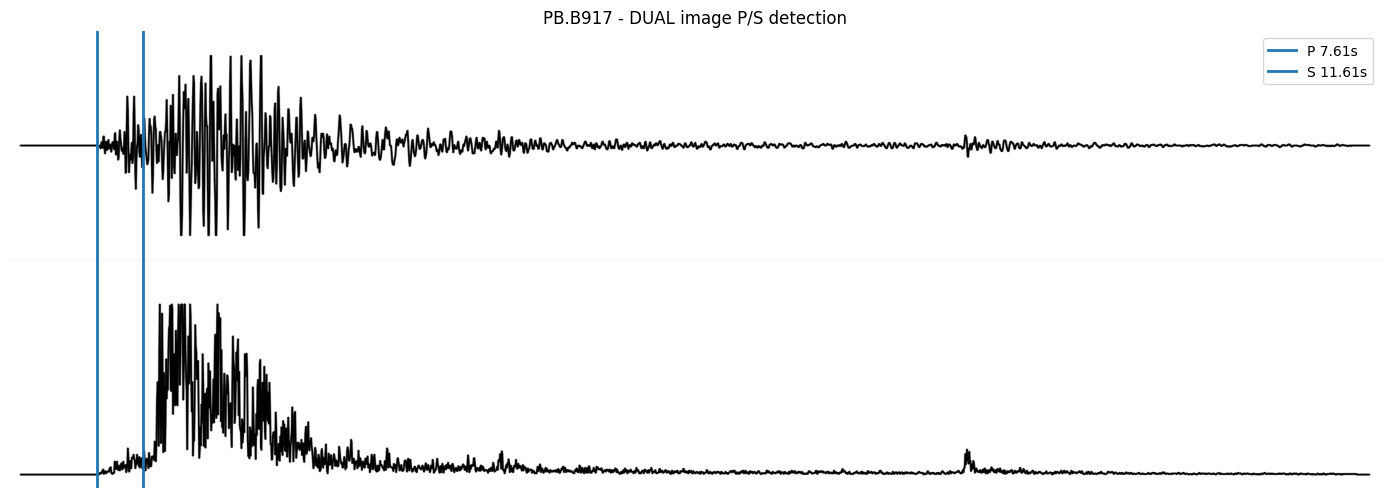

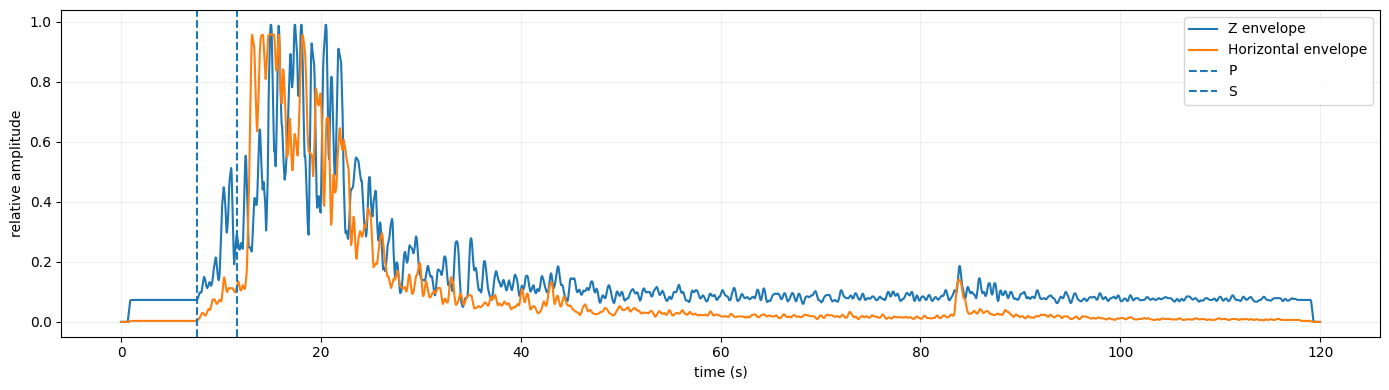


분석 중: PB.B916

관측소 2: PB.B916
P 도착시간 : 9.961 s
S 도착시간 : 15.012 s
S-P        : 5.051 s


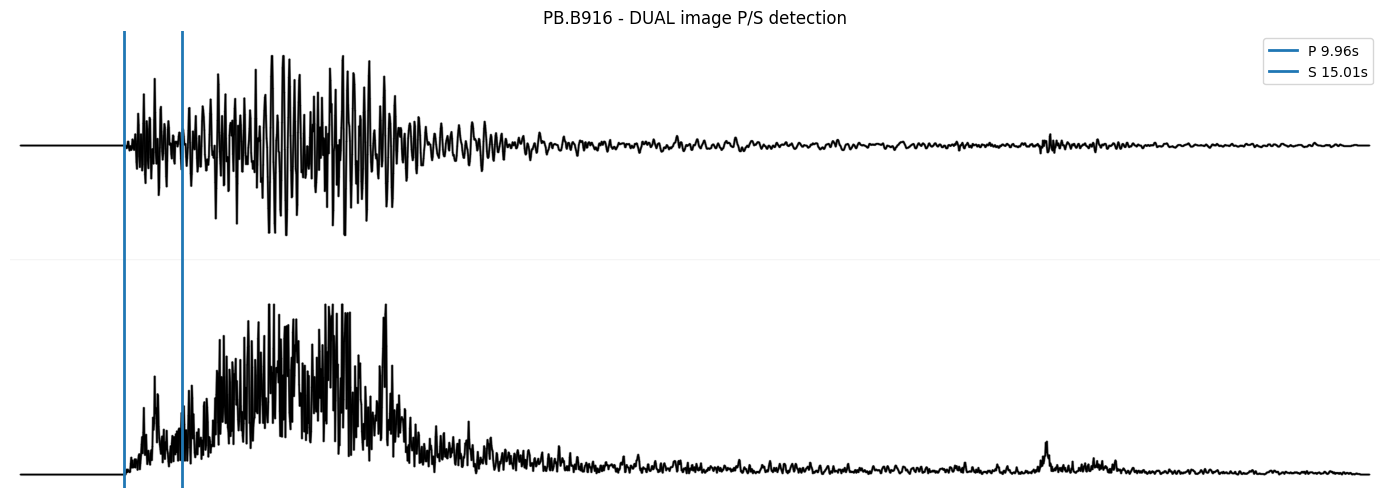

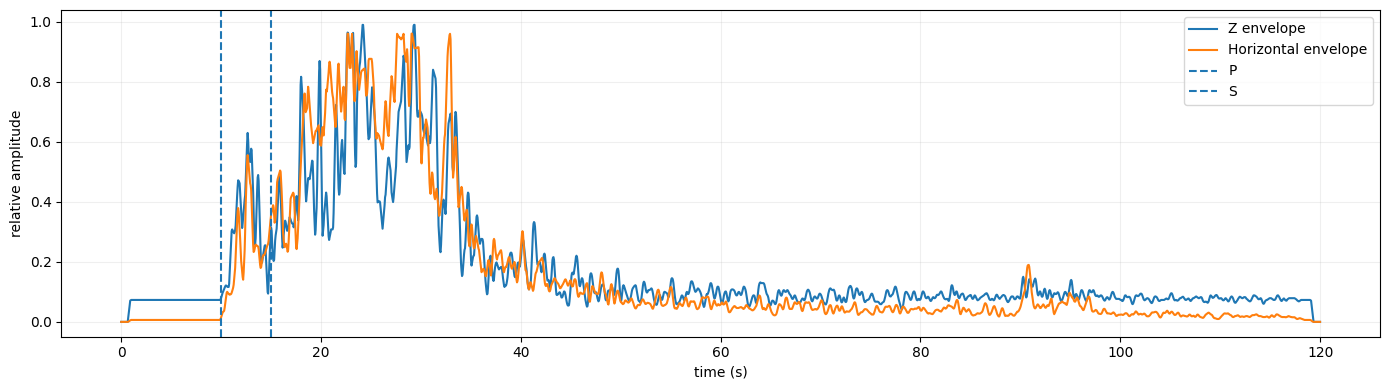


분석 중: NN.QSM

관측소 3: NN.QSM
P 도착시간 : 9.861 s
S 도착시간 : 13.862 s
S-P        : 4.001 s


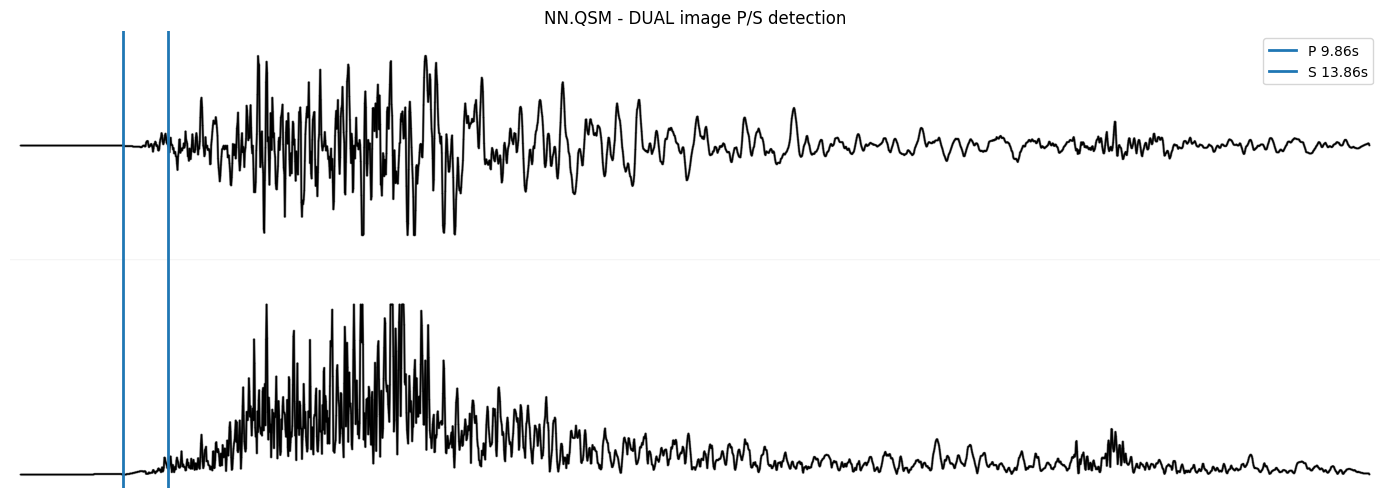

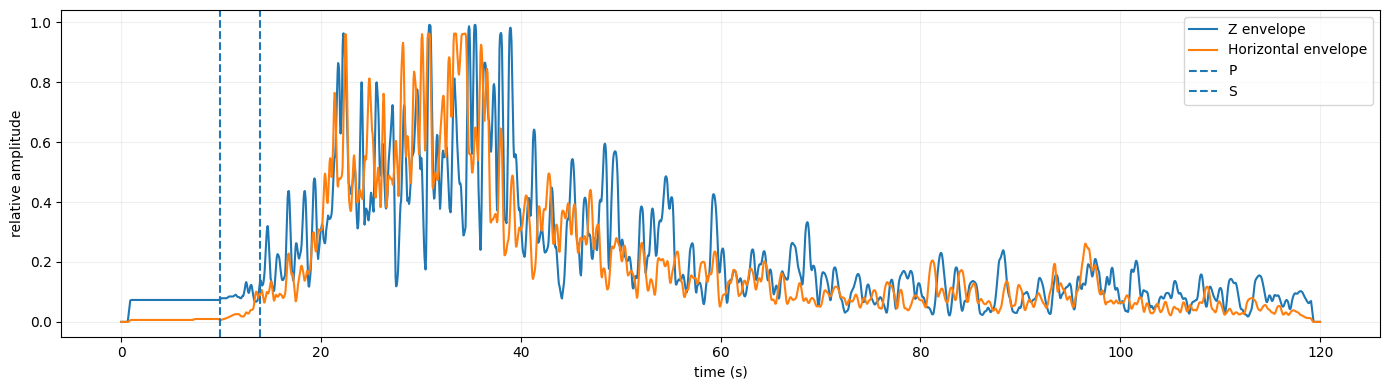

In [10]:
import os

base = "real_earthquake_dual_v6/ridgecrest_2019"

for _, r in df.iterrows():
    station_id = int(r["station_index"])

    image_path = os.path.join(
        base,
        r["dual_program_png"]
    )

    print("\n==============================")
    print("분석 중:", r["name"])
    print("==============================")

    analyzer.analyze_station(
        station_id=station_id,
        image_path=image_path,
        start_time=float(r["plot_start_s"]),
        end_time=float(r["plot_end_s"]),
        show_diagnostics=True
    )


TauP/IASP91 differential location 시작
latitude bounds : 30.41 ~ 41.19
longitude bounds: -122.67 ~ -111.87
depth bounds    : 0.5 ~ 200.0 km

최종 진원 위치 - TauP/IASP91 differential inversion
진앙 위도        : 35.7720°
진앙 경도        : -117.3711°
진원 깊이        : 0.50 km
공통 시간 offset : -0.26 s
S-P RMSE         : 1.79 s
P/S arrival RMSE : 0.92 s
station  distance_deg  obs_p_s  pred_p_s  p_residual_s   obs_s_s  pred_s_s  s_residual_s  obs_sp_s  pred_sp_s  sp_residual_s
PB.B917      0.377862 7.610301  6.980377     -0.629924 11.611301 12.241225      0.629924  4.001000   5.260848       1.259847
PB.B916      0.484534 9.960889  9.025186     -0.935703 15.012152 15.771032      0.758880  5.051263   6.745846       1.694583
 NN.QSM      0.450261 9.860764  8.368191     -1.492573 13.861764 14.636929      0.775165  4.001000   6.268738       2.267738


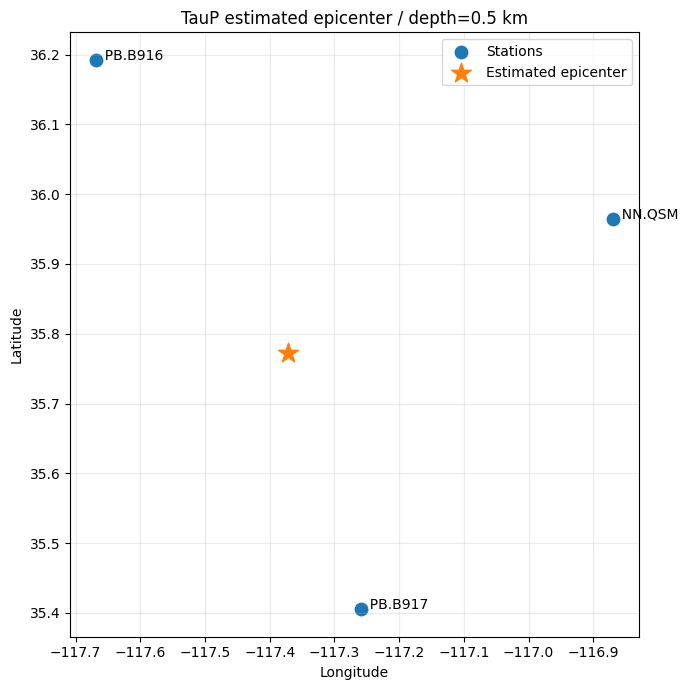

In [11]:
result = analyzer.calculate_hypocenter()

In [12]:
comparison = analyzer.compare_with_reference(
    35.705,
    -117.504,
    10.5
)


기준 진원과 비교
진앙 오차 : 14.12 km
깊이 오차 : 10.00 km
